# 第079课 变分推断与ELBO
从可解析后验检查每一步更新和最终偏差。

解析均值: [0.44444444 0.44444444]
解析协方差: [[ 0.55555556 -0.44444444]
 [-0.44444444  0.55555556]]
证据: -1.5466258635350592


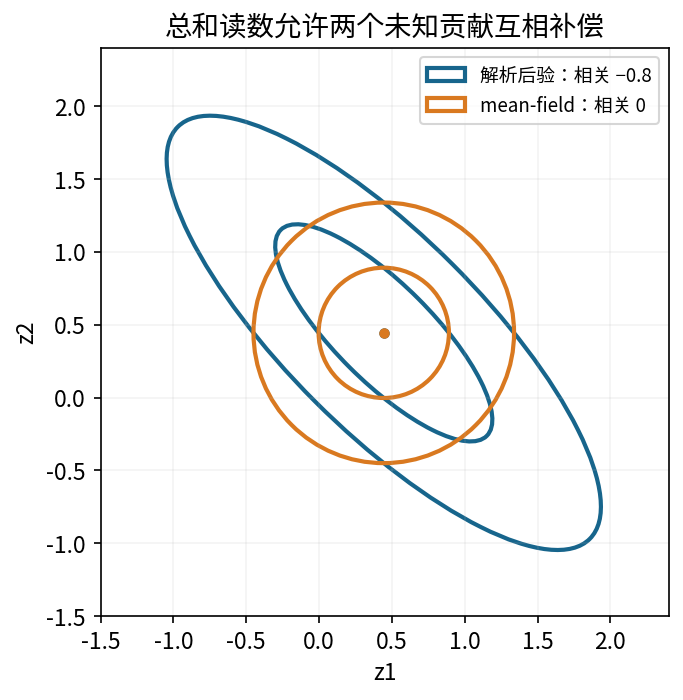

In [1]:
from pathlib import Path
import json, numpy as np
from variational import *
from experiment import run
from IPython.display import display, Image
model=json.loads(Path('data/correlated.json').read_text())
p=posterior(**model)
print('解析均值:',p['mean'])
print('解析协方差:',p['covariance'])
print('证据:',p['log_evidence'])
display(Image(filename='figures/01_geometry.png'))

## 1 两轮手算与坐标轨迹

{'sweep': 0, 'coordinate': None, 'mean': [0.0, 0.0], 'variance': [1.0, 1.0]}
{'sweep': 1, 'coordinate': 0, 'mean': [0.8, 0.0], 'variance': [0.2, 1.0]}
{'sweep': 1, 'coordinate': 1, 'mean': [0.8, 0.15999999999999998], 'variance': [0.2, 0.2]}
{'sweep': 2, 'coordinate': 0, 'mean': [0.672, 0.15999999999999998], 'variance': [0.2, 0.2]}
{'sweep': 2, 'coordinate': 1, 'mean': [0.672, 0.26239999999999997], 'variance': [0.2, 0.2]}
是否已收敛: False


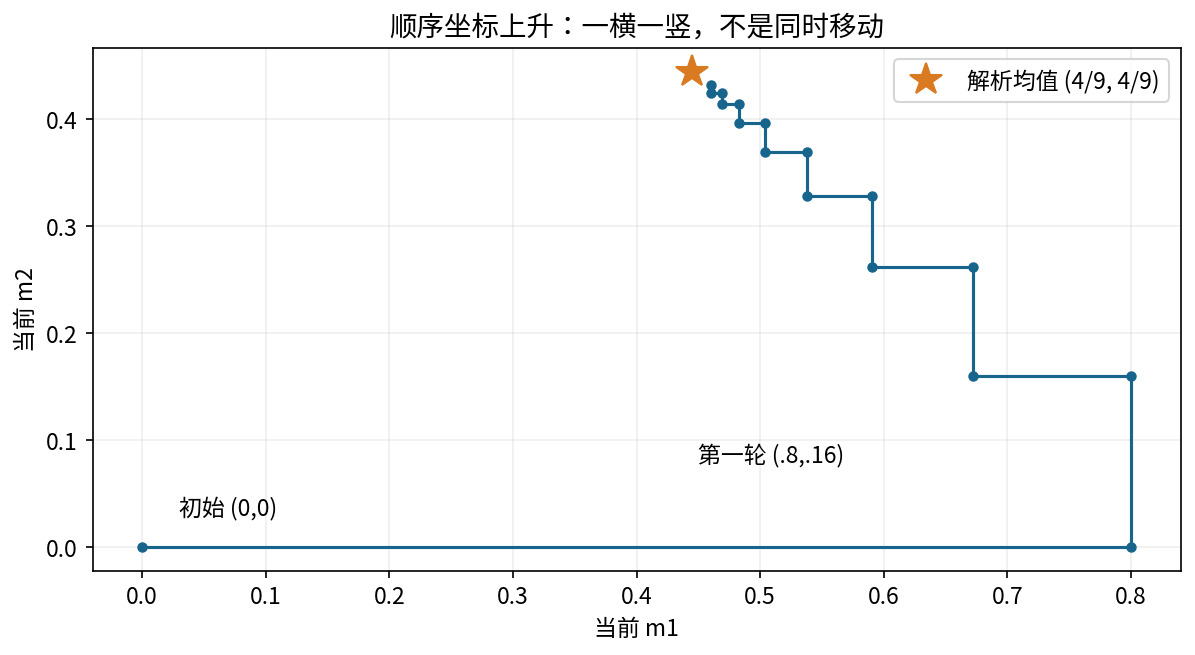

In [2]:
short=coordinate_mean_field(p['precision'],p['natural_mean'],max_sweeps=2)
for row in short['trace']: print(row)
print('是否已收敛:',short['converged'])
display(Image(filename='figures/03_coordinates.png'))

q_mean [0.44444444444574904, 0.44444444444340075]
q_variance [0.2, 0.2]
variance_ratio [0.36, 0.36]
elbo -2.0574514873010505
kl_q_p 0.5108256237659907
max_mean_error 1.3045675650857902e-12
max_decomposition_error 1.1102230246251565e-15


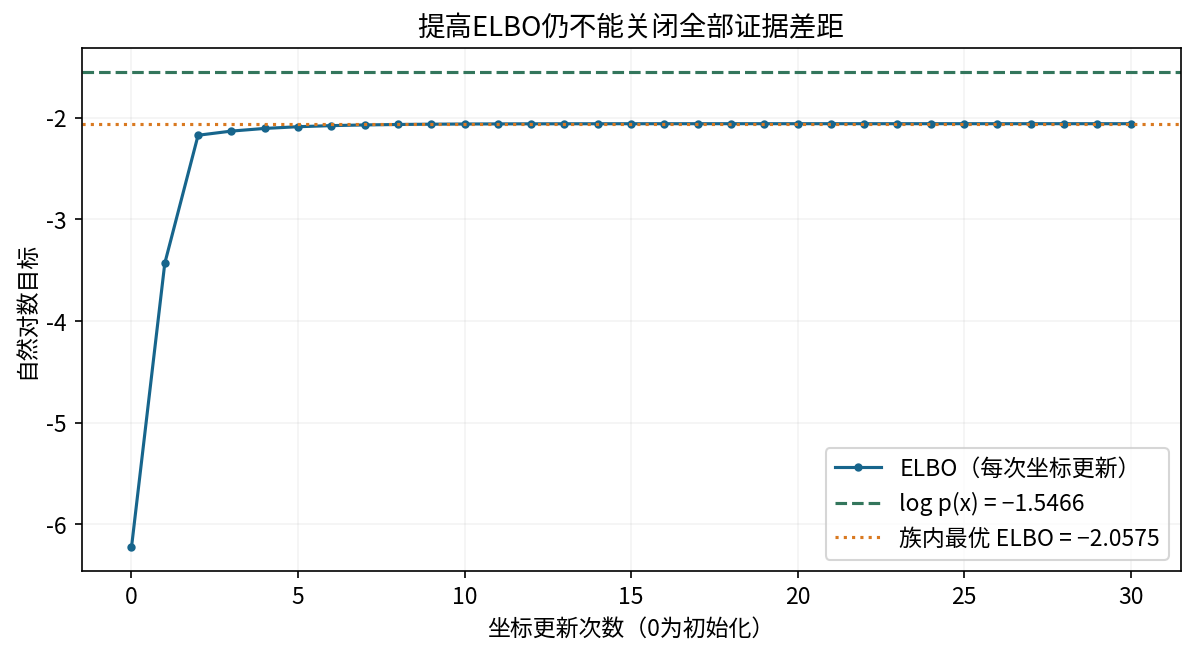

In [3]:
r=run()
for key in ['q_mean','q_variance','variance_ratio','elbo','kl_q_p','max_mean_error','max_decomposition_error']: print(key,r[key])
display(Image(filename='figures/02_elbo.png'))

## 2 方向与最终统计量

另一方向最优: {'mean': [0.4444444444444445, 0.44444444444444436], 'variance': [0.5555555555555556, 0.5555555555555556], 'kl_p_q': 0.5108256237659907, 'kl_q_p': 1.266952154011787}
线性组合: {
  "sum": {
    "exact": {
      "mean": 0.8888888888888888,
      "variance": 0.2222222222222222
    },
    "mean_field": {
      "mean": 0.8888888888891497,
      "variance": 0.4
    }
  },
  "difference": {
    "exact": {
      "mean": 1.1102230246251565e-16,
      "variance": 2.0
    },
    "mean_field": {
      "mean": 2.3482882305359e-12,
      "variance": 0.4
    }
  },
  "future_sum_observation": {
    "exact": {
      "mean": 0.8888888888888888,
      "variance": 0.4722222222222222
    },
    "mean_field": {
      "mean": 0.8888888888891497,
      "variance": 0.65
    }
  }
}
独立对照: {'kl_q_p': 0.0, 'q_mean': [0.8, -0.8], 'q_variance': [0.2, 0.2]}


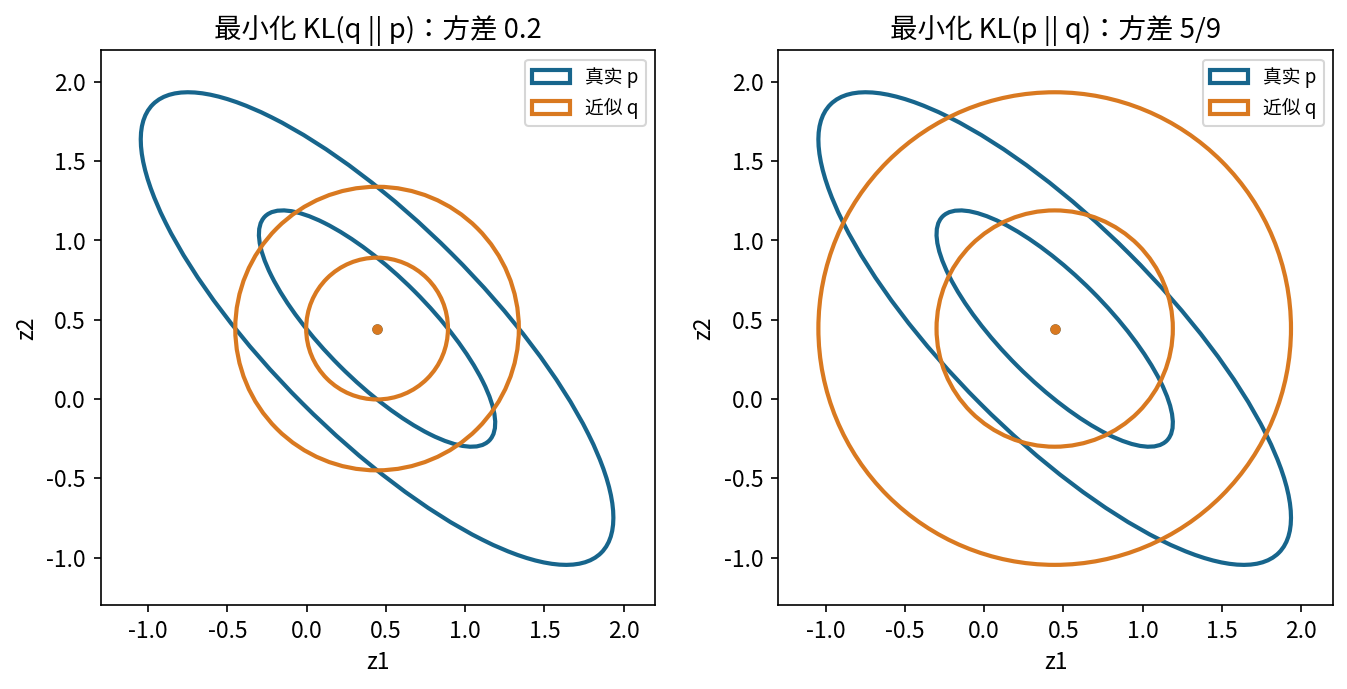

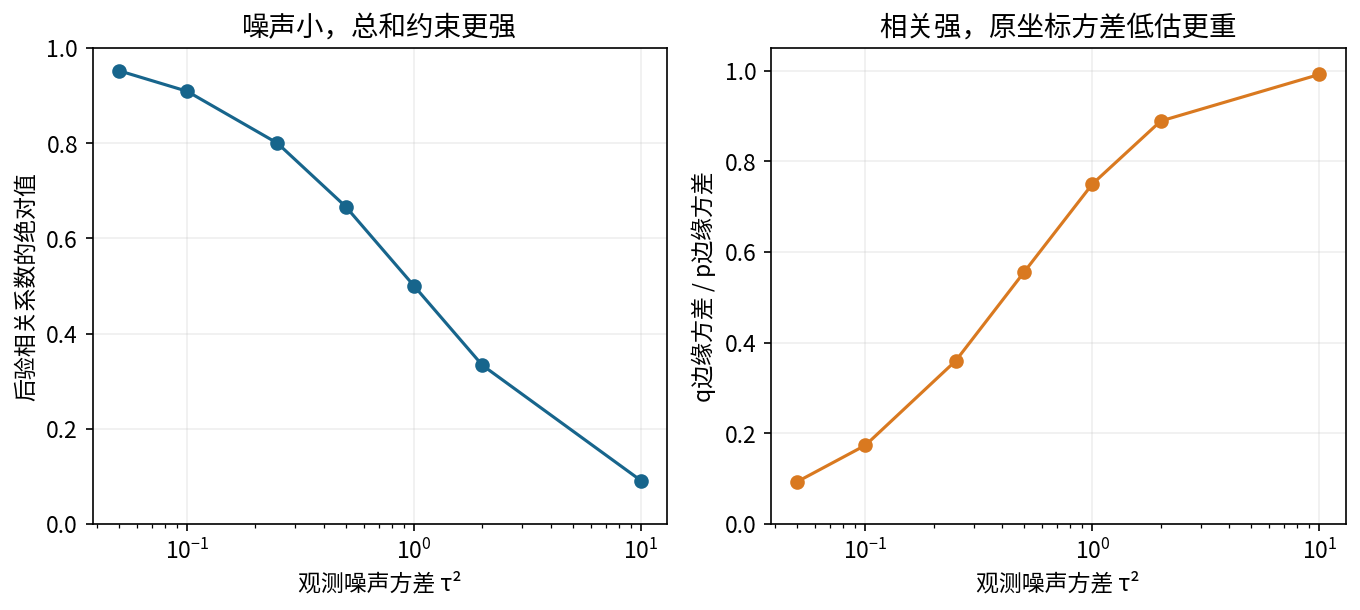

In [4]:
print('另一方向最优:',r['forward_kl_optimum'])
print('线性组合:',json.dumps(r['linear_functionals'],indent=2))
print('独立对照:',r['independent_control'])
display(Image(filename='figures/04_direction.png'))
display(Image(filename='figures/05_noise.png'))

In [5]:
try:
    coordinate_mean_field([[1.,2.],[2.,1.]],[0.,0.])
except ValueError as error:
    print('正确拒绝非正定矩阵:',error)
else:
    raise RuntimeError('invalid matrix accepted')
import unittest
from test_experiment import Checks
tests=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(Checks))
if not tests.wasSuccessful(): raise RuntimeError('tests failed')

正确拒绝非正定矩阵: precision must be positive definite


.........
----------------------------------------------------------------------
Ran 9 tests in 0.196s

OK


## 结论
本例均值恢复，但方差和相关性没有恢复。不同线性组合的方差偏差甚至方向相反。